In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO

def get_col_names(file_path):
    df = pd.read_csv(file_path)

    return df.columns.to_list()

In [2]:
get_col_names("favorites.csv")

['Timestamp', 'language', 'problem']

In [3]:
example_df = pd.DataFrame(
    {
        "x": [1, 2, 3, 4],
        "y": [3, 5, 7, 9],
    }
)
def calculate_slope_and_intercept(data_frame, x_column, y_column):
    x_values = data_frame[x_column]
    y_values = data_frame[y_column]
    x_mean = x_values.mean()
    y_mean = y_values.mean()
    x_deviations = x_values - x_mean
    y_deviations = y_values - y_mean
    cross_products = x_deviations * y_deviations
    x_squared_deviations = x_deviations ** 2
    numerator = cross_products.sum()
    denomenator = x_squared_deviations.sum()
    slope = numerator / denomenator
    intercept = y_mean - (slope * x_mean)
    return slope , intercept

In [4]:
sample = calculate_slope_and_intercept(example_df, "x", "y")

In [5]:
y_pred = sample[0] * example_df["x"] + sample[1]
residuals = example_df["y"] - y_pred

residuals_square = residuals ** 2
RMSE = np.sqrt((1/len(example_df)) * residuals_square.sum())
RMSE

np.float64(0.0)

In [6]:
noisy_df = pd.DataFrame(
    {
        "x": [1, 2, 3, 4],
        "y": [3, 5, 8, 9],
    }
)
sample_2 = calculate_slope_and_intercept(noisy_df, "x", "y")

In [7]:
y_pred_2 = sample_2[0] * noisy_df["x"] + sample_2[1]
residuals_2 = noisy_df["y"] - y_pred_2

residuals_square = residuals_2 ** 2
rmse = np.sqrt((1 / len(example_df)) * residuals_square.sum())
rmse, sample_2

(np.float64(0.41833001326703756), (np.float64(2.1), np.float64(1.0)))

In [8]:
y_mean = noisy_df["y"].mean()
y_deviation = noisy_df["y"] - y_mean
y_sst = (y_deviation ** 2).sum()

y_pred = sample_2[0] * noisy_df["x"] + sample_2[1]
residuals = noisy_df["y"] - y_pred_2
y_sse = (residuals_2 ** 2).sum()

In [9]:
R_square = 1 - (y_sse / y_sst)
R_square

np.float64(0.9692307692307692)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
def fit_linear_regression(data_frame, x_column, y_column):
    model = LinearRegression()
    return model.fit(data_frame[[x_column]], data_frame[y_column])

In [12]:
model = fit_linear_regression(noisy_df, "x", "y")

In [13]:
print(model.coef_[0], model.intercept_, model.predict)



2.0999999999999996 1.0000000000000009 <bound method MultiOutputLinearModel.predict of LinearRegression()>


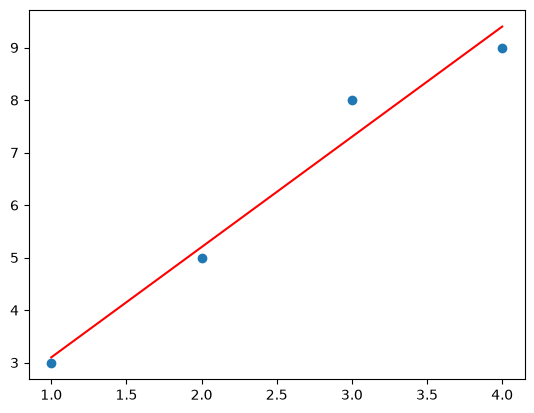

In [17]:
figure, axis = plt.subplots()

axis.scatter(noisy_df["x"], noisy_df["y"])
axis.plot(noisy_df["x"], y_pred_2, color="red")



In [19]:
image = BytesIO()
figure.savefig(image, format="png")
image.seek(0)
plt.close(figure)

In [20]:
len(image.getvalue())

14725